## Лабораторна робота № 2. Математичне моделювання епідемій (модель1 та модель2)
Григоренко В. О. КМ-23

### Завдання.
Промоделювати розвиток епідемії, розв’язавши задачу Коші для системи 
диференційних рівнянь для різних наборів параметрів моделі 

$(N, r, c, q, u(t)=const)$ та керувань $u(t) \in U=\{u:0 \le u \le u_{max} < 1\}$.

В тому числі зі зворотним зв’язком $(u(I/N), r(I/N), c(I/N))$.

**Рекомендації** щодо вибору параметрів моделі $r, c, q, q_0, u, N, T$.

Бажано орієнтуватися на епідемічну ситуацію з короно-вірусом COVID-19,

Наприклад,
* $r \in [0.001, 50]$, (дослідити, як радикальне зменшення числа контактів впливає на хід епідемії)
* $c \in [0.5, 0.9]$, (у COVID-19 дуже висока ймовірність передачі)
* $q \in [0.05, 0.1]$, (у COVID-19 досить повільний процес одужання, $1/q$ - середній час одужання)
* $q_0 \in [0.01, 0.1]$, (відсоток смертельних випадків коливається від 1% до 10%)
* $u \in [0, 0.01]$, (для COVID-19 практично ще немає вакцини)
* $N \in [10^3, 10^6]$, (як виглядає епідемічний процес для невеликих міст і для міст мільйонників)
* $T \in [30, 300]$ (моделювання потрібно вести до моменту закінчення епідемії).

#### **Порядок виконання роботи.**

##### 1. Обрати модель

Будемо використовувати Модель 1 у вигляді диференціальних рівнянь:

$$\frac{dS}{dt} = -S \cdot p(I) - S \cdot u(t)$$
$$\frac{dI}{dt} = S \cdot p(I) - \alpha I - \beta I$$
$$\frac{dR}{dt} = \alpha I + u(t) S$$
$$\frac{dD}{dt} = \beta I$$

де $p(I) = - \frac{r \ln(1-c)}{N} I$

Та Модель 2. Інваріантна форма (незалежно від розміру популяції) рівнянь SIR-моделі <br>
Позначимо $s = S/N$, $i = I/N$, $\rho = R/N$, $d = D/N$.
Тоді $s(t) + i(t) + \rho(t) + d(t) = 1$.

Система диференціальних рівнянь набуває вигляду:
$$\frac{ds}{dt} = -s \cdot p(i) - s \cdot u(t)$$
$$\frac{di}{dt} = s \cdot p(i) - \alpha i - \beta i$$
$$\frac{d\rho}{dt} = \alpha i + u(t)s$$
$$\frac{dd}{dt} = \beta i$$
де інтенсивність зараження тепер залежить від частки хворих: $p(i) = -i \cdot r \ln(1-c)$.

**Репродуктивне число. Теорема Хеткота**

Введемо параметр $\sigma$ (базове репродуктивне число $R_0$):
$$\sigma = R_0 = \frac{-r \ln(1-c)}{\alpha + \beta}$$
* Якщо $\sigma \cdot s(0) \le 1$, епідемія згасає ($i(t) \to 0$).
* Якщо $\sigma \cdot s(0) > 1$, частка хворих зростає до пікового значення:
$$i_{max} = s(0) + i(0) - \frac{1}{\sigma} - \frac{\ln(\sigma s(0))}{\sigma}$$

##### 2. Обрати значення параметрів моделі $(N, r, c, q, q_0, \alpha, \beta, u_{max})$ відповідно їх змісту (орієнтуватися на пандемію COVID-19).

In [30]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

N = 41_000_000     # Орієнтовне населення України у 2021 році
r = 2.0            # Інтенсивність контактів
c = 0.5            # Ймовірність зараження при контакті
alpha = 0.07       # Ймовірність одужання (приблизно 1/14 днів)
beta = 0.019       
u_const = 0.001    # Константна частка вакцинації/ізоляції в одиницю часу
u_const_2 = 0.0    # Для теореми Хеткота

##### 3. Обрати початкові значення, наприклад, $I(0)>0$, $S(0)=N-I(0)$, $J(0)=0$, $R(0)=0$, $D(0)=0$.

In [31]:
# Дані для моделі 1 станом на 26.02.2021
total_cases = 1_342_016
recovered_total = 1_168_321
deaths_total = 25_888

I0 = total_cases - recovered_total - deaths_total  # 147 807
R0 = recovered_total                               # 1 168 321
D0 = deaths_total                                  # 25 888
S0 = N - I0 - R0 - D0                              # 39 657 984

y0 = [S0, I0, R0, D0]

# Початкові значення для моделі 2
N_ua = 41_000_000
I0_abs = 147_807
R0_abs = 1_168_321
D0_abs = 25_888
S0_abs = N_ua - I0_abs - R0_abs - D0_abs

# Перехід до інваріантних змінних
i0 = I0_abs / N_ua
rho0 = R0_abs / N_ua
d0 = D0_abs / N_ua
s0 = S0_abs / N_ua

y0_inv = [s0, i0, rho0, d0]

##### 4. Обрати проміжок часу $[0, T]$.

In [32]:
T_end = 200
t_span = (0, T_end)
t_eval = np.linspace(0, T_end, T_end * 10) # Точки для більш гладкого графіка

##### 5. Обрати програму для розв'язання нелінійної системи диференційних рівнянь (solver, наприклад, ode23 в системі Matlab, або відповідну програму в інших системах програмування).

In [33]:
def sir_model(t, y, N, r, c, alpha, beta, u):
    S, I, R, D = y
    
    # Розрахунок інтенсивності зараження
    p_I = - (r * np.log(1 - c) * I) / N
    
    # Система диференціальних рівнянь
    dSdt = -S * p_I - S * u
    dIdt = S * p_I - alpha * I - beta * I
    dRdt = alpha * I + u * S
    dDdt = beta * I
    
    return [dSdt, dIdt, dRdt, dDdt]

def sir_invariant_model(t, y, r, c, alpha, beta, u):
    s, i, rho, d = y
    
    # Інтенсивність зараження p(i)
    # Зверніть увагу: тут немає ділення на N, бо i - це вже частка
    p_i = -i * r * np.log(1 - c)
    
    dsdt = -s * p_i - s * u
    didt = s * p_i - alpha * i - beta * i
    drhodt = alpha * i + u * s
    dddt = beta * i
    
    return [dsdt, didt, drhodt, dddt]

##### 6. Розв'язати задачу Коші на відрізку часу $[0, T]$.

In [34]:
solution = solve_ivp(
    sir_model, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(N, r, c, alpha, beta, u_const),
    method='RK45' # Метод Рунге-Кутта
)

t = solution.t
S = solution.y[0]
I = solution.y[1]
R = solution.y[2]
D = solution.y[3]

sol_inv = solve_ivp(
    sir_invariant_model, t_span, y0_inv, t_eval=t_eval, 
    args=(r, c, alpha, beta, u_const_2), method='RK45'
)

t = sol_inv.t
s = sol_inv.y[0]
i = sol_inv.y[1]
rho = sol_inv.y[2]
d = sol_inv.y[3]

##### 7. Обчислити основні характеристики епідемічного процесу для обраного набору параметрів моделі <br> (пік процесу - $I_{max} = \max_{t \in [0, T]} I(t)$, $t_{max} = \arg\max_{t \in [0, T]} I(t)$; <br> тривалість епідемії; кінцевий результат епідемії, <br> $S(\infty), I(\infty), J(\infty), R(\infty), D(\infty)$).

In [35]:
I_max = np.max(I)
t_max = t[np.argmax(I)]

S_end = S[-1]
I_end = I[-1]
R_end = R[-1]
D_end = D[-1]

print(f"Основні характеристики епідемії:")
print(f"Пік хворих (I_max): {int(I_max)} людей")
print(f"День піку (t_max): {t_max:.1f} день")
print(f"Кінцевий стан (на {T_end} день):")
print(f"  S(∞) : {int(S_end)}")
print(f"  I(∞) Хворі: {int(I_end)}")
print(f"  R(∞) Одужалі/Ізольовані: {int(R_end)}")
print(f"  D(∞) Померлі: {int(D_end)}")

Основні характеристики епідемії:
Пік хворих (I_max): 29888694 людей
День піку (t_max): 6.7 день
Кінцевий стан (на 200 день):
  S(∞) : 9
  I(∞) Хворі: 1
  R(∞) Одужалі/Ізольовані: 32514084
  D(∞) Померлі: 8485904


In [36]:
# Аналітичний розрахунок для моделі 2

# 1. Репродуктивне число
sigma = - (r * np.log(1 - c)) / (alpha + beta)
print(f"Теорема Хеткота")
print(f"Репродуктивне число (R0) = {sigma:.3f}")

# Перевірка умови початку епідемії
if sigma * s0 > 1:
    print(f"Умова σ * s(0) = {sigma * s0:.3f} > 1. Епідемія зростатиме.")
    
    # 2. Аналітичний розрахунок максимальної частки хворих (i_max)
    i_max_theory = s0 + i0 - (1 / sigma) - (np.log(sigma * s0) / sigma)
    print(f"Теоретичний пік i_max: {i_max_theory * 100:.2f}% населення")
else:
    print(f"Умова σ * s(0) = {sigma * s0:.3f} <= 1. Епідемія згасатиме.")

# 3. Граничні значення
rho_inf_theory = alpha / (alpha + beta)
d_inf_theory = beta / (alpha + beta)

print(f"\nТеоретичний граничний розподіл (якщо s(∞) -> 0):")
print(f"ρ(∞) = {rho_inf_theory * 100:.2f}% (вижили з імунітетом)")
print(f"d(∞) = {d_inf_theory * 100:.2f}% (померли)")

# Чисельний розрахунок
i_max_empirical = np.max(i)
print(f"\nРезультати чисельного моделювання")
print(f"Емпіричний пік i_max:  {i_max_empirical * 100:.2f}% населення")
print(f"Кінцеве s(∞):          {s[-1] * 100:.2f}%")
print(f"Кінцеве ρ(∞):          {rho[-1] * 100:.2f}%")
print(f"Кінцеве d(∞):          {d[-1] * 100:.2f}%")

# Похибка
error = abs(i_max_theory - i_max_empirical)
print(f"\nПохибка: {error:.6f}")

Теорема Хеткота
Репродуктивне число (R0) = 15.576
Умова σ * s(0) = 15.066 > 1. Епідемія зростатиме.
Теоретичний пік i_max: 73.25% населення

Теоретичний граничний розподіл (якщо s(∞) -> 0):
ρ(∞) = 78.65% (вижили з імунітетом)
d(∞) = 21.35% (померли)

Результати чисельного моделювання
Емпіричний пік i_max:  73.27% населення
Кінцеве s(∞):          0.00%
Кінцеве ρ(∞):          79.21%
Кінцеве d(∞):          20.79%

Похибка: 0.000154


##### 8. Побудувати графіки функцій $S(t), I(t), R(t), D(t)$. На графіках вказати назву графіку, назву осей координат, легенду, значення основних параметрів моделі.

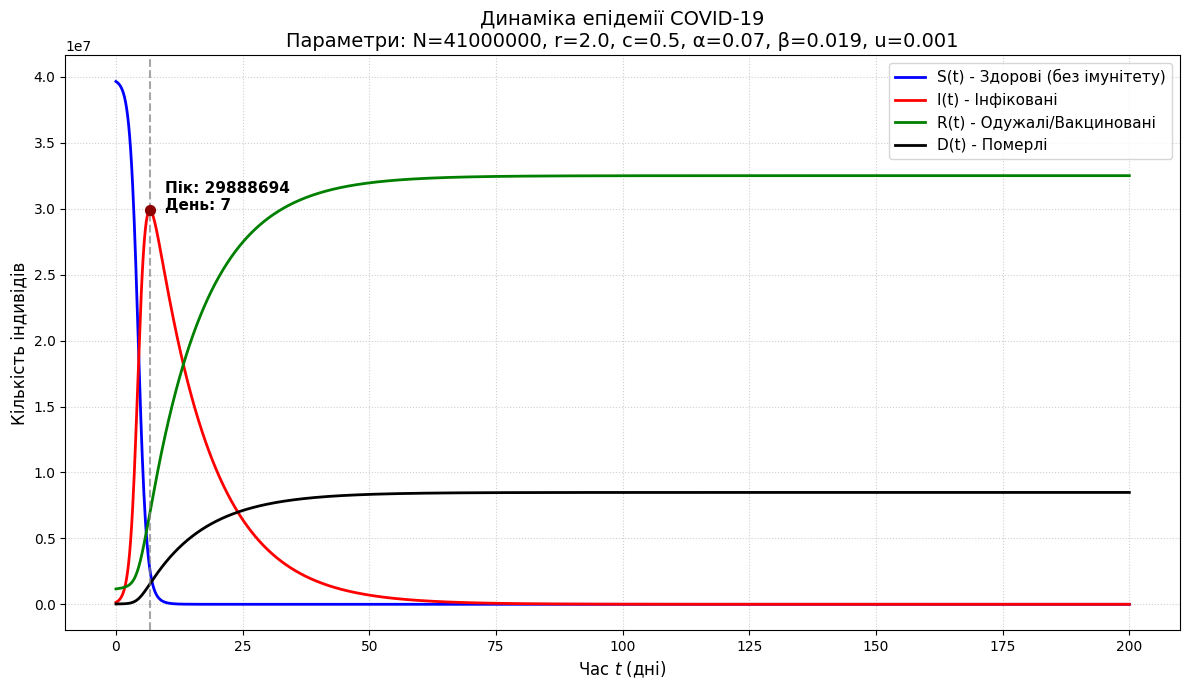

In [37]:
plt.figure(figsize=(12, 7))

# Побудова кривих
plt.plot(t, S, label='S(t) - Здорові (без імунітету)', color='blue', linewidth=2)
plt.plot(t, I, label='I(t) - Інфіковані', color='red', linewidth=2)
plt.plot(t, R, label='R(t) - Одужалі/Вакциновані', color='green', linewidth=2)
plt.plot(t, D, label='D(t) - Померлі', color='black', linewidth=2)

# Додавання інформації про пік
plt.axvline(x=t_max, color='gray', linestyle='--', alpha=0.7)
plt.scatter(t_max, I_max, color='darkred', s=50, zorder=5)
plt.text(t_max + 3, I_max, f'Пік: {int(I_max)}\nДень: {t_max:.0f}', fontsize=11, fontweight='bold')

# Оформлення графіка
plt.title(f'Динаміка епідемії COVID-19\nПараметри: N={N}, r={r}, c={c}, α={alpha}, β={beta}, u={u_const}', fontsize=14)
plt.xlabel('Час $t$ (дні)', fontsize=12)
plt.ylabel('Кількість індивідів', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

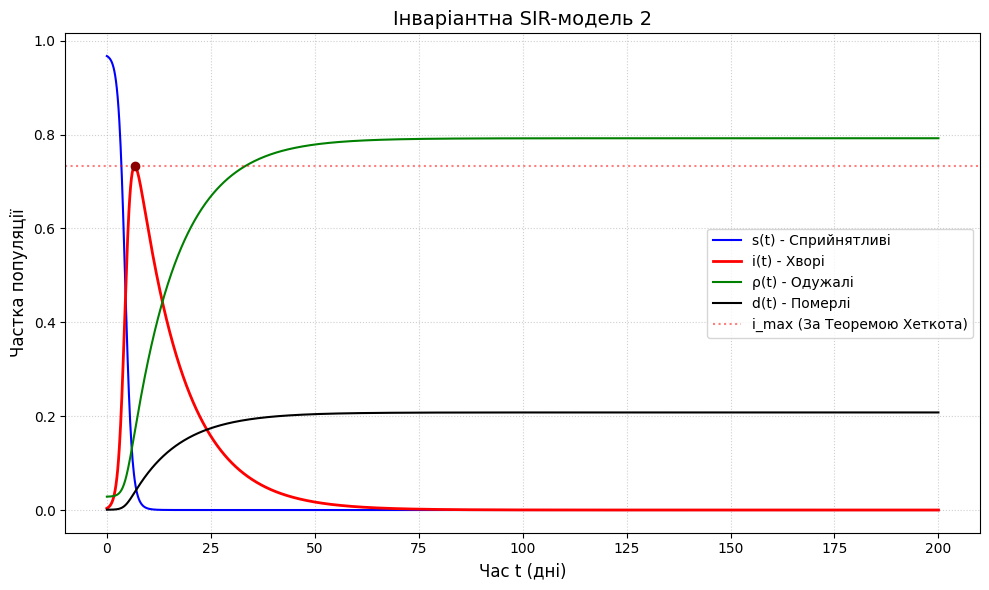

In [38]:
# Візуалізація для Моделі 2
plt.figure(figsize=(10, 6))
plt.plot(t, s, label='s(t) - Сприйнятливі', color='blue')
plt.plot(t, i, label='i(t) - Хворі', color='red', linewidth=2)
plt.plot(t, rho, label='ρ(t) - Одужалі', color='green')
plt.plot(t, d, label='d(t) - Померлі', color='black')

# Позначення теоретичного піку
t_peak = t[np.argmax(i)]
plt.scatter(t_peak, i_max_empirical, color='darkred', zorder=5)
plt.axhline(y=i_max_theory, color='red', linestyle=':', alpha=0.5, label='i_max (За Теоремою Хеткота)')

plt.title('Інваріантна SIR-модель 2', fontsize=14)
plt.xlabel('Час t (дні)', fontsize=12)
plt.ylabel('Частка популяції', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

##### 9. Дослідити зміни розвитку епідемії (картини) для різних значень параметрів моделі $(N, r, c, q, q_0, u(t)=const)$.


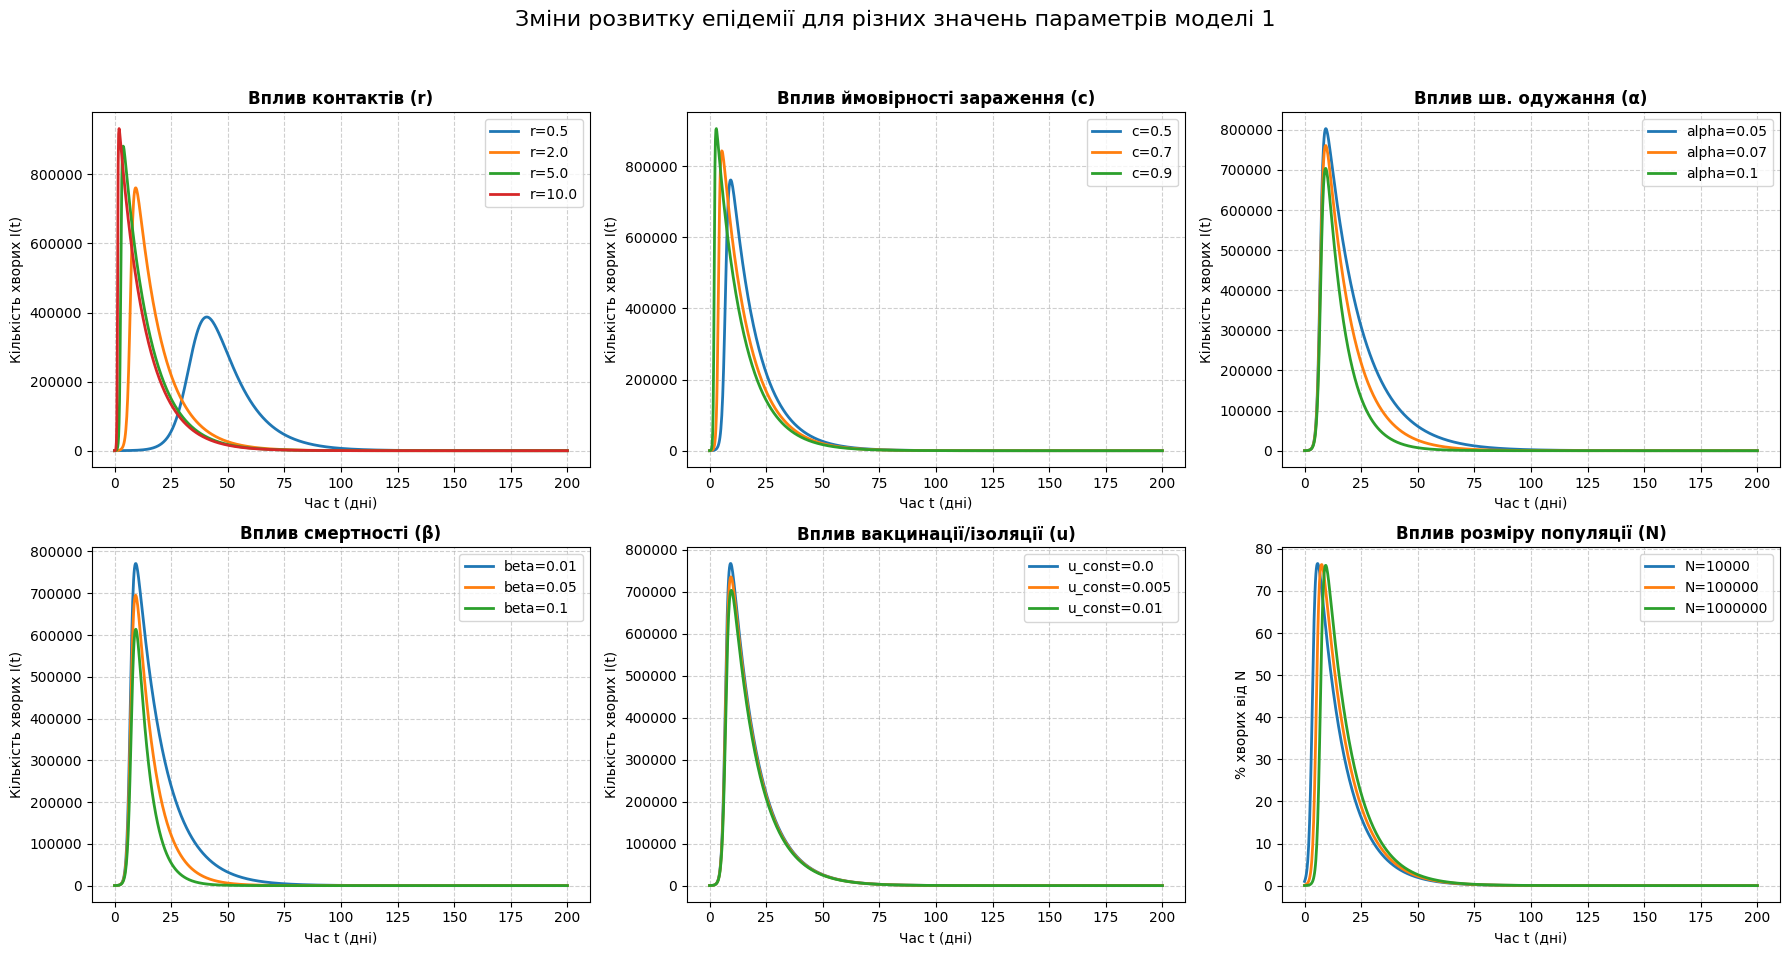

In [39]:
# Для моделі 1

def simulate_epidemic(r, c, alpha, beta, u_const, N=1_000_000, T_end=200):
    I0 = 100
    y0 = [N - I0, I0, 0, 0]
    t_span = (0, T_end)
    t_eval = np.linspace(0, T_end, T_end * 5)
    
    sol = solve_ivp(
        sir_model, t_span, y0, t_eval=t_eval, 
        args=(N, r, c, alpha, beta, u_const), method='RK45'
    )
    return sol.t, sol.y[1]

base_params = {'r': 2.0, 'c': 0.5, 'alpha': 0.07, 'beta': 0.015, 'u_const': 0.001, 'N': 1_000_000}

variants = {
    'r': [0.5, 2.0, 5.0, 10.0],                       # Інтенсивність контактів
    'c': [0.5, 0.7, 0.9],                             # Ймовірність передачі
    'alpha': [0.05, 0.07, 0.1],                       # Ймовірність одужання (1/q)
    'beta': [0.01, 0.05, 0.1],                        # Відсоток смертності (q_0)
    'u_const': [0.0, 0.005, 0.01],                    # Вакцинація/ізоляція
    'N': [10_000, 100_000, 1_000_000]                 # Розмір популяції
}

titles = {
    'r': 'Вплив контактів (r)', 'c': 'Вплив ймовірності зараження (c)',
    'alpha': 'Вплив шв. одужання (α)', 'beta': 'Вплив смертності (β)',
    'u_const': 'Вплив вакцинації/ізоляції (u)', 'N': 'Вплив розміру популяції (N)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (param_name, param_values) in enumerate(variants.items()):
    ax = axes[i]
    
    for val in param_values:
        params = base_params.copy()
        params[param_name] = val
        
        t, I = simulate_epidemic(**params)
        
        if param_name == 'N':
            ax.plot(t, I / val * 100, label=f'{param_name}={val}', linewidth=2)
            ax.set_ylabel('% хворих від N')
        else:
            ax.plot(t, I, label=f'{param_name}={val}', linewidth=2)
            ax.set_ylabel('Кількість хворих I(t)')
            
    ax.set_title(titles[param_name], fontsize=12, fontweight='bold')
    ax.set_xlabel('Час t (дні)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.suptitle('Зміни розвитку епідемії для різних значень параметрів моделі 1', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

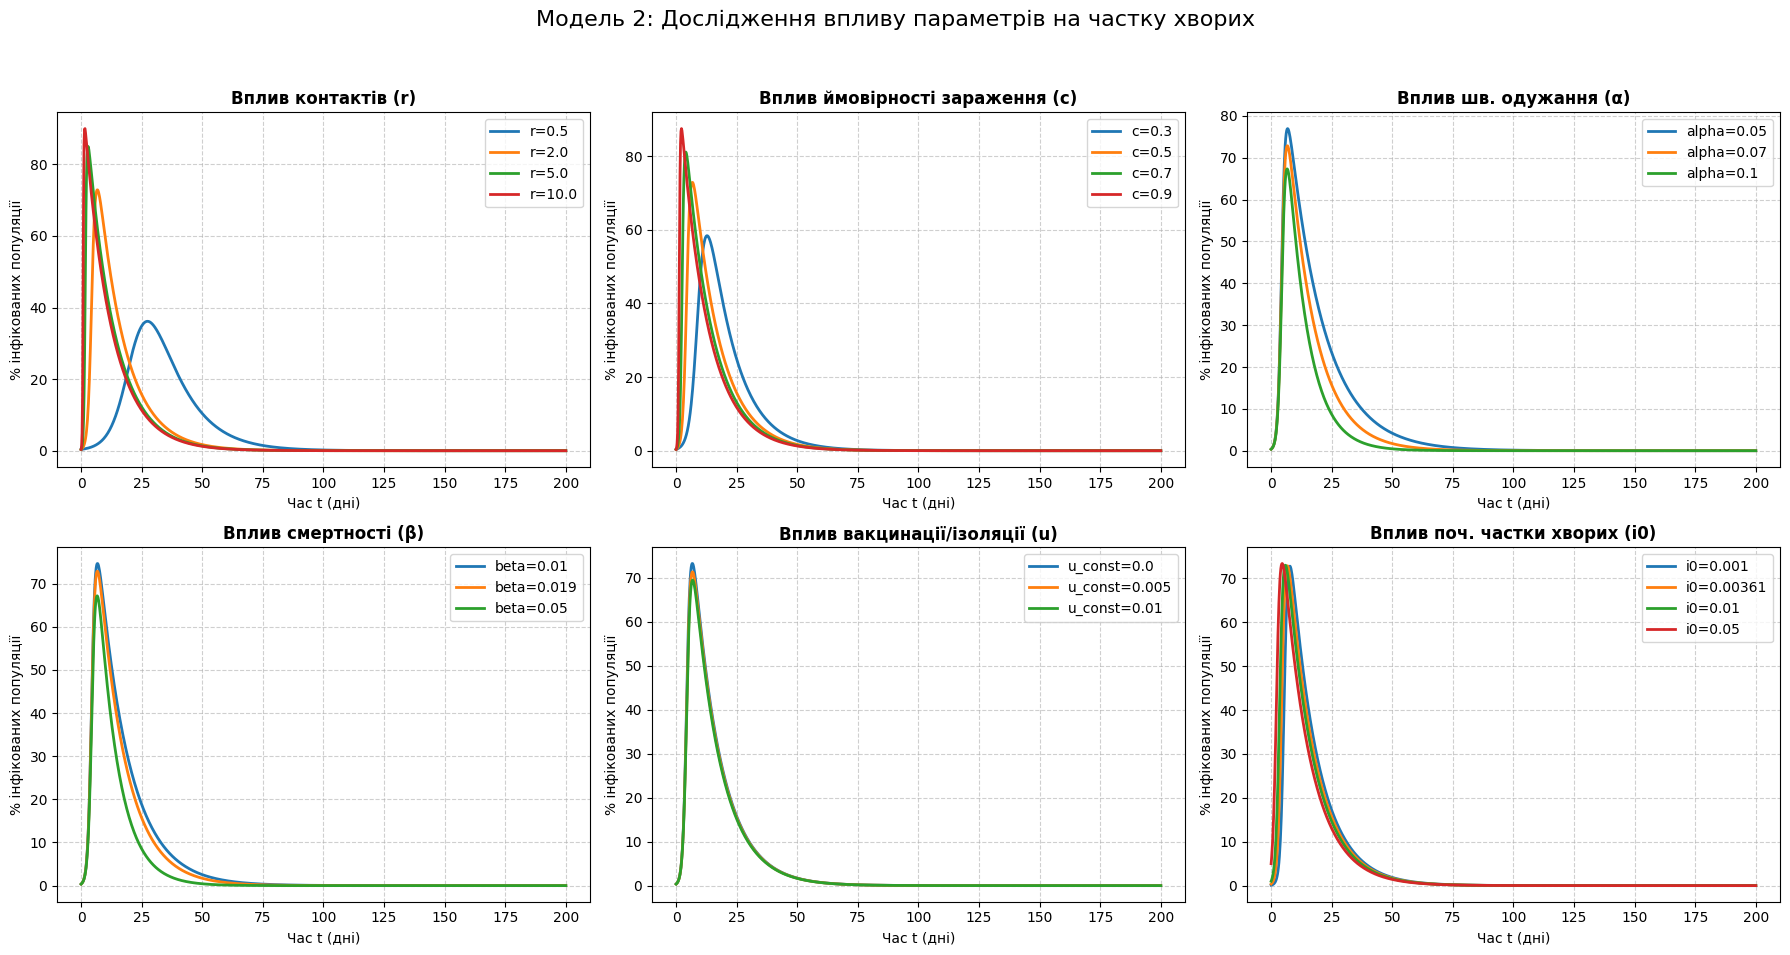

In [40]:
# Для моделі 2
def simulate_invariant_epidemic(r, c, alpha, beta, u_const, i0=0.00361, T_end=200):
    # Початкові частки
    rho0 = 0.02850
    d0 = 0.00063
    s0 = 1.0 - i0 - rho0 - d0 # Сума часток завжди дорівнює 1
    
    y0 = [s0, i0, rho0, d0]
    t_span = (0, T_end)
    t_eval = np.linspace(0, T_end, T_end * 5)
    
    sol = solve_ivp(
        sir_invariant_model, t_span, y0, t_eval=t_eval, 
        args=(r, c, alpha, beta, u_const), method='RK45'
    )
    return sol.t, sol.y[1] * 100 

# Базові параметри для Моделі 2
base_params_inv = {'r': 2.0, 'c': 0.5, 'alpha': 0.07, 'beta': 0.019, 'u_const': 0.001, 'i0': 0.00361}

# Діапазони параметрів для дослідження
variants_inv = {
    'r': [0.5, 2.0, 5.0, 10.0],                       # Інтенсивність контактів
    'c': [0.3, 0.5, 0.7, 0.9],                        # Ймовірність передачі
    'alpha': [0.05, 0.07, 0.1],                       # Швидкість одужання (1/q)
    'beta': [0.01, 0.019, 0.05],                      # Відсоток смертності (q_0)
    'u_const': [0.0, 0.005, 0.01],                    # Вакцинація/ізоляція
    'i0': [0.001, 0.00361, 0.01, 0.05]                # Початкова частка хворих
}

titles_inv = {
    'r': 'Вплив контактів (r)', 'c': 'Вплив ймовірності зараження (c)',
    'alpha': 'Вплив шв. одужання (α)', 'beta': 'Вплив смертності (β)',
    'u_const': 'Вплив вакцинації/ізоляції (u)', 'i0': 'Вплив поч. частки хворих (i0)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (param_name, param_values) in enumerate(variants_inv.items()):
    ax = axes[i]
    
    for val in param_values:
        params = base_params_inv.copy()
        params[param_name] = val
        
        t, i_pct = simulate_invariant_epidemic(**params)
        
        ax.plot(t, i_pct, label=f'{param_name}={val}', linewidth=2)
            
    ax.set_title(titles_inv[param_name], fontsize=12, fontweight='bold')
    ax.set_ylabel('% інфікованих популяції')
    ax.set_xlabel('Час t (дні)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.suptitle('Модель 2: Дослідження впливу параметрів на частку хворих', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##### 10. Дослідити зміни розвитку епідемії (картини) для різних керувань $u(t) \in U=\{u:0 \le u \le u_{max} < 1\}$, в тому числі зі зворотним зв’язком $u(I/N), r(I/N), c(I/N)$.

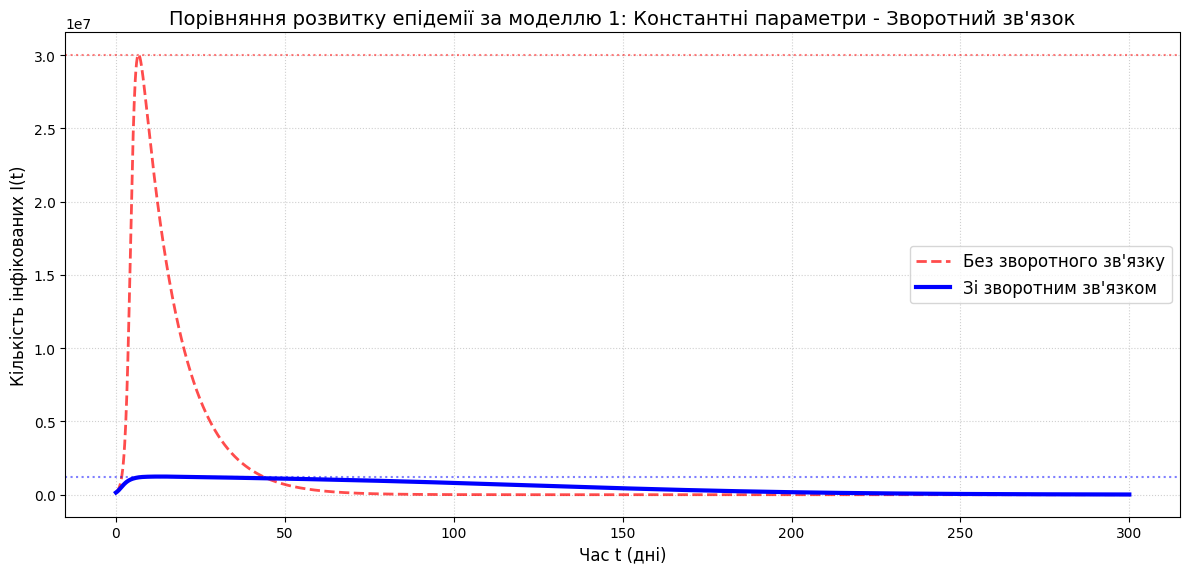

Пікова значення без заходів: 30045471 хворих
Пікова значення зі зворотнім зв'язком: 1239593 хворих


In [41]:
# Функція моделі 1 зі зворотнім зв'язком
def sir_model_feedback(t, y, N, r0, c0, alpha, beta, u_max):
    S, I, R, D = y
    
    # Поточна частка хворих у суспільстві
    i_frac = I / N
    
    # 1. Вакцинація/Ізоляція
    k_u = 0.5
    u_current = min(u_max, k_u * i_frac)
    # 2. Контакти
    k_r = 50.0
    r_current = max(0.5, r0 - k_r * i_frac)
    # 3. Ймовірність зараження
    k_c = 10.0
    c_current = max(0.1, c0 - k_c * i_frac)
    
    p_I = - (r_current * np.log(1 - c_current) * I) / N
    
    # Система рівнянь
    dSdt = -S * p_I - S * u_current
    dIdt = S * p_I - alpha * I - beta * I
    dRdt = alpha * I + u_current * S
    dDdt = beta * I
    
    return [dSdt, dIdt, dRdt, dDdt]

N_ua = 41_000_000
u_max = 0.01
T_end_fb = 300
t_span_fb = (0, T_end_fb)
t_eval_fb = np.linspace(0, T_end_fb, T_end_fb * 10)

# Базова модель
sol_base = solve_ivp(
    sir_model, t_span_fb, y0, t_eval=t_eval_fb, 
    args=(N_ua, 2.0, 0.5, 0.07, 0.019, 0.0), # u=0 для чистоти порівняння
    method='RK45'
)

# Модель зі зворотнім зв'язком
sol_fb = solve_ivp(
    sir_model_feedback, t_span_fb, y0, t_eval=t_eval_fb, 
    args=(N_ua, 2.0, 0.5, 0.07, 0.019, u_max),
    method='RK45'
)

I_base = sol_base.y[1]
I_fb = sol_fb.y[1]

# Графіки
plt.figure(figsize=(12, 6))

plt.plot(sol_base.t, I_base, label='Без зворотного зв\'язку', 
         color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.plot(sol_fb.t, I_fb, label='Зі зворотним зв\'язком', 
         color='blue', linewidth=3)

# Позначення піків
peak_base = np.max(I_base)
peak_fb = np.max(I_fb)
plt.axhline(y=peak_base, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=peak_fb, color='blue', linestyle=':', alpha=0.5)

plt.title("Порівняння розвитку епідемії за моделлю 1: Константні параметри - Зворотний зв'язок", fontsize=14)
plt.xlabel('Час t (дні)', fontsize=12)
plt.ylabel('Кількість інфікованих I(t)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

print(f"Пікова значення без заходів: {int(peak_base)} хворих")
print(f"Пікова значення зі зворотнім зв'язком: {int(peak_fb)} хворих")

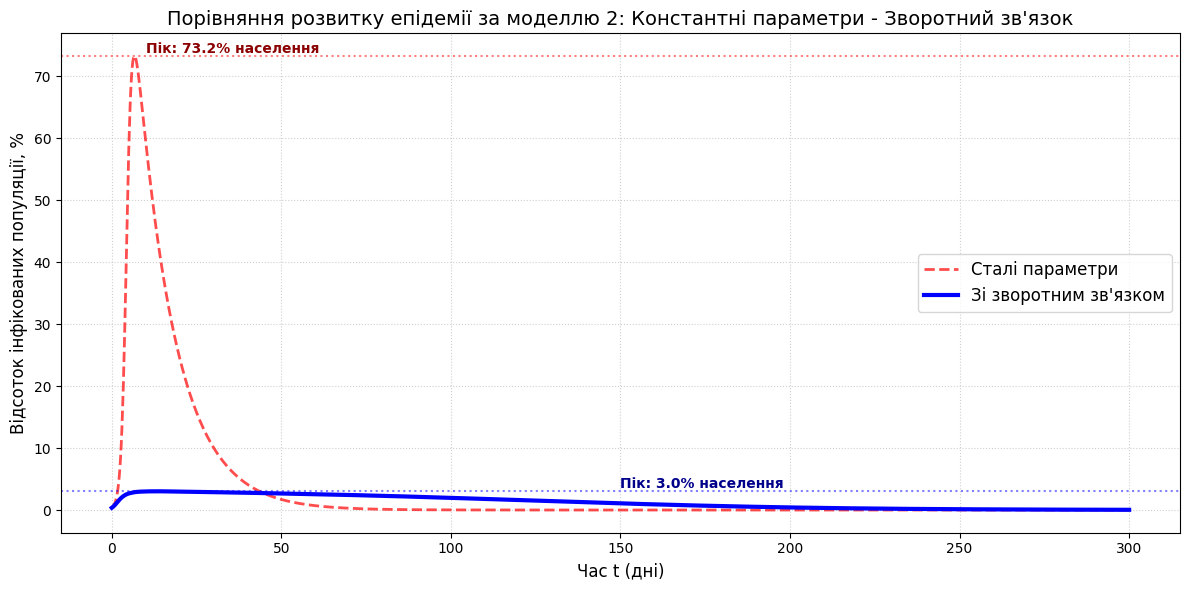

Результати керування епідемією:
Пікова значення без заходів: 73 хворих
Пікова значення зі зворотнім зв'язком: 3 хворих


In [42]:
# Функція інваріантної моделі зі зворотнім зв'язком. Модель 2
def sir_invariant_feedback(t, y, r0, c0, alpha, beta, u_max):
    s, i, rho, d = y
    
    u_current = min(u_max, 0.5 * i)
    r_current = max(0.5, r0 - 50.0 * i) 
    c_current = max(0.1, c0 - 10.0 * i) 
    
    p_i = -i * r_current * np.log(1 - c_current)
    
    # Система диференціальних рівнянь
    dsdt = -s * p_i - s * u_current
    didt = s * p_i - (alpha + beta) * i
    drhodt = alpha * i + u_current * s
    dddt = beta * i
    
    return [dsdt, didt, drhodt, dddt]

# Початкові умови для України (станом на 26.02.2021)
i0_inv = 0.00361
rho0_inv = 0.02850
d0_inv = 0.00063
s0_inv = 1.0 - i0_inv - rho0_inv - d0_inv
y0_inv = [s0_inv, i0_inv, rho0_inv, d0_inv]

# Параметри
r_base = 2.0
c_base = 0.5
alpha_base = 0.07
beta_base = 0.019
u_max_limit = 0.01

T_end_fb = 300
t_span_fb = (0, T_end_fb)
t_eval_fb = np.linspace(0, T_end_fb, T_end_fb * 5)

sol_base_inv = solve_ivp(
    sir_invariant_model, t_span_fb, y0_inv, t_eval=t_eval_fb, 
    args=(r_base, c_base, alpha_base, beta_base, 0.0), 
    method='RK45'
)

sol_fb_inv = solve_ivp(
    sir_invariant_feedback, t_span_fb, y0_inv, t_eval=t_eval_fb, 
    args=(r_base, c_base, alpha_base, beta_base, u_max_limit),
    method='RK45'
)

i_base_pct = sol_base_inv.y[1] * 100
i_fb_pct = sol_fb_inv.y[1] * 100

plt.figure(figsize=(12, 6))

plt.plot(sol_base_inv.t, i_base_pct, label='Сталі параметри', 
         color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.plot(sol_fb_inv.t, i_fb_pct, label='Зі зворотним зв\'язком', 
         color='blue', linewidth=3)

peak_base_pct = np.max(i_base_pct)
peak_fb_pct = np.max(i_fb_pct)

plt.axhline(y=peak_base_pct, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=peak_fb_pct, color='blue', linestyle=':', alpha=0.5)

plt.text(10, peak_base_pct + 0.5, f'Пік: {peak_base_pct:.1f}% населення', color='darkred', fontweight='bold')
plt.text(150, peak_fb_pct + 0.5, f'Пік: {peak_fb_pct:.1f}% населення', color='darkblue', fontweight='bold')

plt.title("Порівняння розвитку епідемії за моделлю 2: Константні параметри - Зворотний зв'язок", fontsize=14)
plt.xlabel('Час t (дні)', fontsize=12)
plt.ylabel('Відсоток інфікованих популяції, %', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

# Вивід ключових метрик
print(f"Результати керування епідемією:")
print(f"Пікова значення без заходів: {int(peak_base_pct)} хворих")
print(f"Пікова значення зі зворотнім зв'язком: {int(peak_fb_pct)} хворих")